In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Load the dataset
# Ensure the CSV file is in the same folder as your script
df = pd.read_csv('healthcare_data@1.csv')

Section A: Data Understanding & Cleaning

In [26]:
# 1. Missing Values
print("Missing Values per Column:")
print(df.isnull().sum())
print("-" * 30)

Missing Values per Column:
Patient_ID           0
Age                  0
Gender               0
BMI                  0
Blood_Pressure       0
Cholesterol_Level    0
Diabetes             0
Smoker               0
Hospital_Visits      0
Treatment_Cost       0
dtype: int64
------------------------------


In [27]:
#2. Average Patient Age
avg_age = df['Age'].mean()
print(f"Average Patient Age: {avg_age:.2f}")

Average Patient Age: 53.20


In [28]:
# 3. Gender Count
gender_counts = df['Gender'].value_counts()
print(f"Gender Distribution:\n{gender_counts}")

Gender Distribution:
Gender
Male      258
Female    242
Name: count, dtype: int64


In [29]:
# 4. Highest Treatment Cost
highest_cost_idx = df['Treatment_Cost'].idxmax()
highest_cost_patient = df.loc[highest_cost_idx]
print(f"Patient with highest cost: {highest_cost_patient['Patient_ID']} (${highest_cost_patient['Treatment_Cost']})")

Patient with highest cost: P0253 ($19991.33)


In [30]:
# 5. Average BMI (Diabetic vs Non-Diabetic)
avg_bmi_diabetes = df.groupby('Diabetes')['BMI'].mean()
print(f"Average BMI by Diabetes Status:\n{avg_bmi_diabetes}")
print("-" * 30)

Average BMI by Diabetes Status:
Diabetes
No     27.972932
Yes    27.222222
Name: BMI, dtype: float64
------------------------------


In [31]:
# Section B: Statistical Analysis

In [33]:
# 6. Correlation (Blood Pressure and Cholesterol)
correlation = df['Blood_Pressure'].corr(df['Cholesterol_Level'])
print(f"Correlation (BP vs Cholesterol): {correlation:.4f}")

Correlation (BP vs Cholesterol): -0.0642


In [34]:
# 7. Mean Treatment Cost (Smoker vs Non-Smoker)
mean_cost_smoker = df.groupby('Smoker')['Treatment_Cost'].mean()
print(f"Mean Cost by Smoking Status:\n{mean_cost_smoker}")

Mean Cost by Smoking Status:
Smoker
No     10897.082949
Yes    10585.728346
Name: Treatment_Cost, dtype: float64


In [35]:
# 8. Highest Hospital Visits by Age Group
# Define age bins
bins = [0, 18, 35, 50, 65, 100]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [36]:
visits_by_group = df.groupby('Age_Group', observed=False)['Hospital_Visits'].sum()
print(f"Highest visits by Age Group: {visits_by_group.idxmax()}")

Highest visits by Age Group: 65+


In [37]:
# 9. BMI Variance and Standard Deviation
bmi_variance = df['BMI'].var()
bmi_std = df['BMI'].std()
print(f"BMI Variance: {bmi_variance:.2f}, Std Dev: {bmi_std:.2f}")

BMI Variance: 53.32, Std Dev: 7.30


In [38]:
diabetes_pct = (df['Diabetes'] == 'Yes').mean() * 100
print(f"Percentage of Diabetic Patients: {diabetes_pct:.2f}%")
print("-" * 30)

Percentage of Diabetic Patients: 46.80%
------------------------------


# Section C: Visualizations

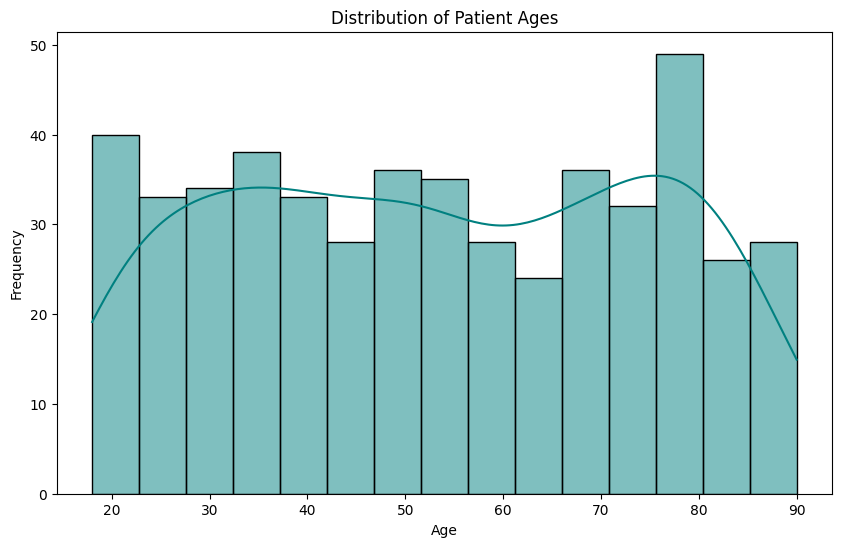

In [39]:
# 11. Histogram of Patient Ages
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=15, kde=True, color='teal')
plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

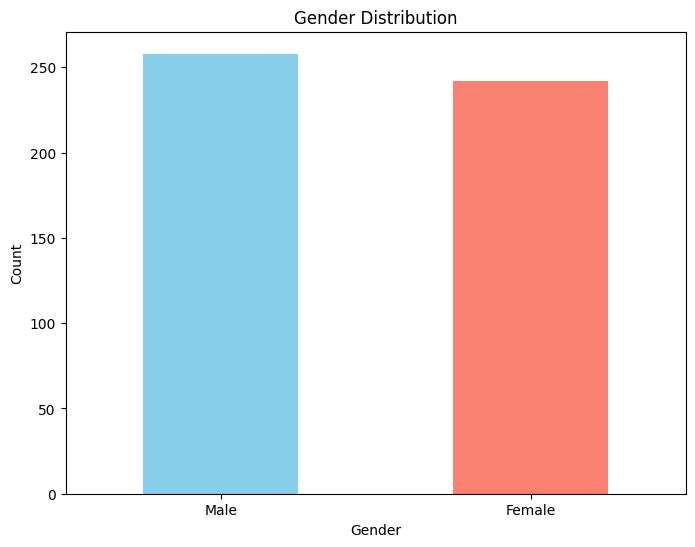

In [40]:
# 12. Bar Chart of Male vs Female Patients
plt.figure(figsize=(8, 6))
gender_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

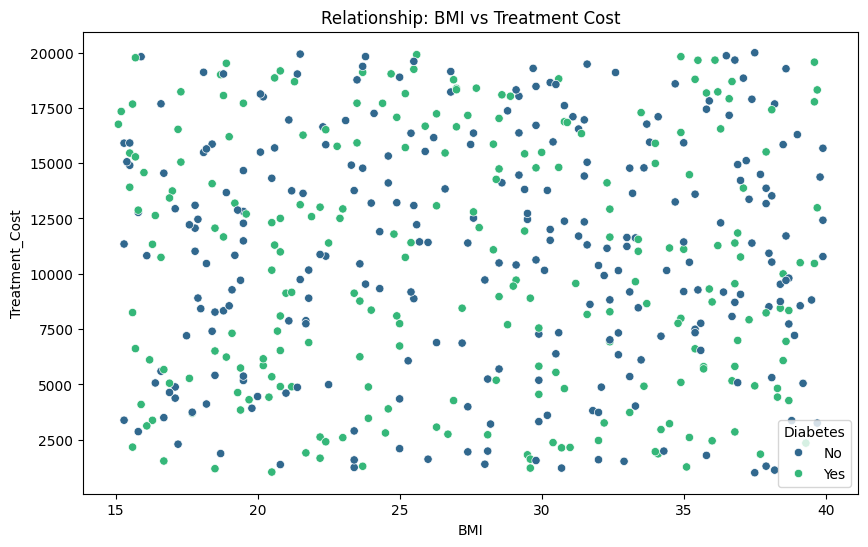

In [41]:
# 13. Scatter Plot of BMI vs Treatment Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='BMI', y='Treatment_Cost', hue='Diabetes', palette='viridis')
plt.title('Relationship: BMI vs Treatment Cost')
plt.show()

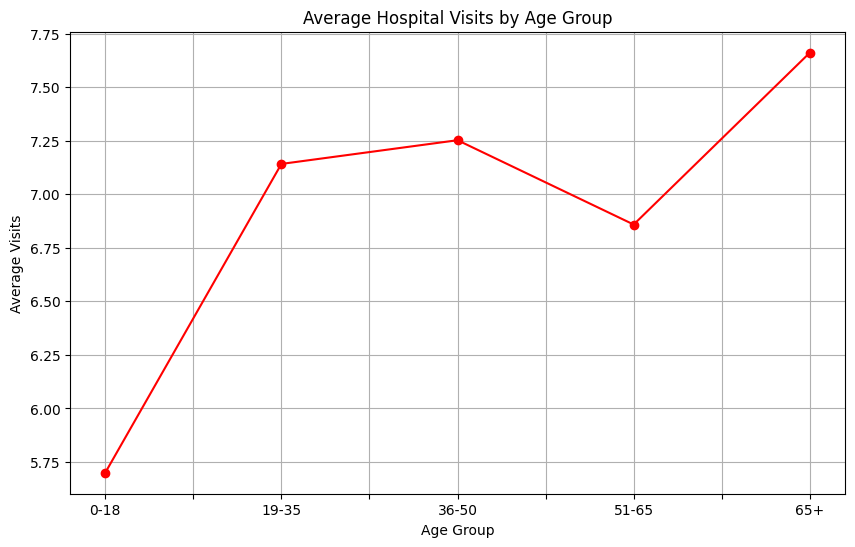

In [42]:
# 14. Line Chart: Avg Hospital Visits by Age Group
plt.figure(figsize=(10, 6))
df.groupby('Age_Group', observed=False)['Hospital_Visits'].mean().plot(kind='line', marker='o', color='red')
plt.title('Average Hospital Visits by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Visits')
plt.grid(True)
plt.show()

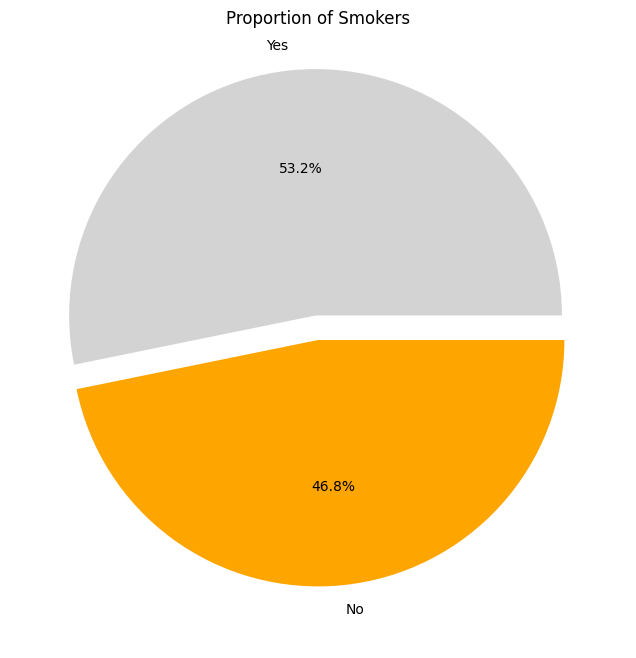

In [43]:
# 15. Pie Chart: Smokers vs Non-Smokers
plt.figure(figsize=(8, 8))
df['Smoker'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgrey', 'orange'], explode=(0.1, 0))
plt.title('Proportion of Smokers')
plt.ylabel('')
plt.show()

In [44]:
# Section D: Conceptual Snippets